In [ ]:
# importing pandas library
import pandas as pd

In [ ]:
# importing numpy library
import numpy as np

In [ ]:
# importing data (Onboarding the dataset)
df=pd.read_csv(r"C:\Users\SUNIL\OneDrive\Desktop\Internship-Project\AI-Keyword_searched with top queries.csv")
df

,query,search interest,increase percent
0,ai gemini,100,Breakout
1,gemini ai,94,Breakout
2,gemini,93,Breakout
3,ai photo,48,1400%
4,ai image,48,750%
5,google ai,47,110%
6,ai chatgpt,37,Breakout
7,chatgpt ai,36,Breakout
8,ai remaker,31,Breakout
9,remaker ai,30,Breakout


In [ ]:
#  To see Variable/Column Names of the df
df.columns

Index(['query', 'search interest', 'increase percent'], dtype='object')

In [8]:
# To see first two column names 'Product', 'Sales Person'
df.columns[0:2]

Index(['query', 'search interest'], dtype='object')

In [ ]:
# To Check Variable/Column data Types
df.dtypes

query               object
search interest      int64
increase percent    object
dtype: object

In [ ]:
# To check no of rows and columns
df.shape

(50, 3)

In [ ]:
# By default head( ) shows first 5 rows.
df.head()

,query,search interest,increase percent
0,ai gemini,100,Breakout
1,gemini ai,94,Breakout
2,gemini,93,Breakout
3,ai photo,48,1400%
4,ai image,48,750%


In [ ]:
# By default tail( ) shows first 5 rows.
df.tail()

,query,search interest,increase percent
45,gamma,9,Breakout
46,remaker ai face,8,Breakout
47,generative ai,8,Breakout
48,remaker ai face swap,8,Breakout
49,leonardo ai,7,Breakout


In [18]:
# To Extract Unique Values
df['query'].unique()

array(['ai gemini', 'gemini ai', 'gemini', 'ai photo', 'ai image',
       'google ai', 'ai chatgpt', 'chatgpt ai', 'ai remaker',
       'remaker ai', 'what is ai', 'chat ai', 'ai chat', 'ai studio',
       'image generator ai', 'open ai', 'ai image generator', 'gpt',
       'bard ai', 'gemini ai photo', 'face swap ai', 'bard',
       'google gemini', 'ai face swap', 'google gemini ai', 'ai tools',
       'google studio ai', 'grok ai', 'google ai studio', 'grok',
       'chat gpt', 'chat gpt ai', 'ai video generator', 'character ai',
       'claude ai', 'blackbox ai', 'bing', 'ai photo editor',
       'perplexity ai', 'claude', 'bing ai', 'perplexity', 'ai website',
       'meta ai', 'gamma ai', 'gamma', 'remaker ai face', 'generative ai',
       'remaker ai face swap', 'leonardo ai'], dtype=object)

In [23]:
# # To show column wise total missing values(null) of df
df.isnull().sum()

query               0
search interest     0
increase percent    0
dtype: int64

In [24]:
# To show column wise total missing values(not null) of df
df.notnull().sum()

query               50
search interest     50
increase percent    50
dtype: int64

In [26]:
# To remove entire row null values
df1=df.dropna
df1

<bound method DataFrame.dropna of                    query  search interest increase percent
0              ai gemini              100         Breakout
1              gemini ai               94         Breakout
2                 gemini               93         Breakout
3               ai photo               48            1400%
4               ai image               48             750%
5              google ai               47             110%
6             ai chatgpt               37         Breakout
7             chatgpt ai               36         Breakout
8             ai remaker               31         Breakout
9             remaker ai               30         Breakout
10            what is ai               27              -5%
11               chat ai               22            1100%
12               ai chat               21            1050%
13             ai studio               19            1850%
14    image generator ai               18         Breakout
15               open 

In [ ]:
# Removing duplicates
df.drop_duplicates

<bound method DataFrame.drop_duplicates of                    query  search interest increase percent
0              ai gemini              100         Breakout
1              gemini ai               94         Breakout
2                 gemini               93         Breakout
3               ai photo               48            1400%
4               ai image               48             750%
5              google ai               47             110%
6             ai chatgpt               37         Breakout
7             chatgpt ai               36         Breakout
8             ai remaker               31         Breakout
9             remaker ai               30         Breakout
10            what is ai               27              -5%
11               chat ai               22            1100%
12               ai chat               21            1050%
13             ai studio               19            1850%
14    image generator ai               18         Breakout
15           

In [29]:
df.rename(columns={"search interest": "search_interest","increase percent": "increase_percent"},inplace=True)
df1

<bound method DataFrame.dropna of                    query  search_interest increase_percent
0              ai gemini              100         Breakout
1              gemini ai               94         Breakout
2                 gemini               93         Breakout
3               ai photo               48            1400%
4               ai image               48             750%
5              google ai               47             110%
6             ai chatgpt               37         Breakout
7             chatgpt ai               36         Breakout
8             ai remaker               31         Breakout
9             remaker ai               30         Breakout
10            what is ai               27              -5%
11               chat ai               22            1100%
12               ai chat               21            1050%
13             ai studio               19            1850%
14    image generator ai               18         Breakout
15               open 

In [30]:
df

,query,search_interest,increase_percent
0,ai gemini,100,Breakout
1,gemini ai,94,Breakout
2,gemini,93,Breakout
3,ai photo,48,1400%
4,ai image,48,750%
5,google ai,47,110%
6,ai chatgpt,37,Breakout
7,chatgpt ai,36,Breakout
8,ai remaker,31,Breakout
9,remaker ai,30,Breakout


In [ ]:
# Data Type Correction
# Remove % Symbol
df['increase_percent'] = df['increase_percent'].str.replace('%', '', regex=False)

In [ ]:
# Convert to Numeric Type
# Why errors='coerce'?
# If any invalid value exists, it converts it to NaN
# Prevents program crashes

df['increase_percent'] = pd.to_numeric(df['increase_percent'], errors='coerce')
df.dtypes

query                object
search_interest       int64
increase_percent    float64
dtype: object

In [ ]:
# Outlier Detection (IQR Method)
# Calculate Q1, Q3 and IQR
Q1 = df['search_interest'].quantile(0.25)
Q3 = df['search_interest'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)


Q1: 10.0
Q3: 20.5
IQR: 10.5


In [38]:
# Define Lower and Upper Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -5.75
Upper Bound: 36.25


In [39]:
# Detect Outliers
outliers = df[(df['search_interest'] < lower_bound) | 
              (df['search_interest'] > upper_bound)]

print("Outliers Detected:")
display(outliers)

Outliers Detected:


,query,search_interest,increase_percent
0,ai gemini,100,NaN
1,gemini ai,94,NaN
2,gemini,93,NaN
3,ai photo,48,1400.0
4,ai image,48,750.0
5,google ai,47,110.0
6,ai chatgpt,37,NaN


In [ ]:
# Feature Engineering – Creating growth_category

df['growth_category'] = np.where(
    df['increase_percent'] > 100, 'High Growth',
    np.where(df['increase_percent'] >= 50, 'Medium Growth', 'Low Growth')
)
df

,query,search_interest,increase_percent,growth_category
0,ai gemini,100,NaN,Low Growth
1,gemini ai,94,NaN,Low Growth
2,gemini,93,NaN,Low Growth
3,ai photo,48,1400.0,High Growth
4,ai image,48,750.0,High Growth
5,google ai,47,110.0,High Growth
6,ai chatgpt,37,NaN,Low Growth
7,chatgpt ai,36,NaN,Low Growth
8,ai remaker,31,NaN,Low Growth
9,remaker ai,30,NaN,Low Growth


In [44]:
# Correlation Analysis
# Ensure Both Columns are Numeric
# Calculate Correlation Matrix

correlation = df[['search_interest', 'increase_percent']].corr()
print(correlation)

                  search_interest  increase_percent
search_interest          1.000000         -0.271046
increase_percent        -0.271046          1.000000


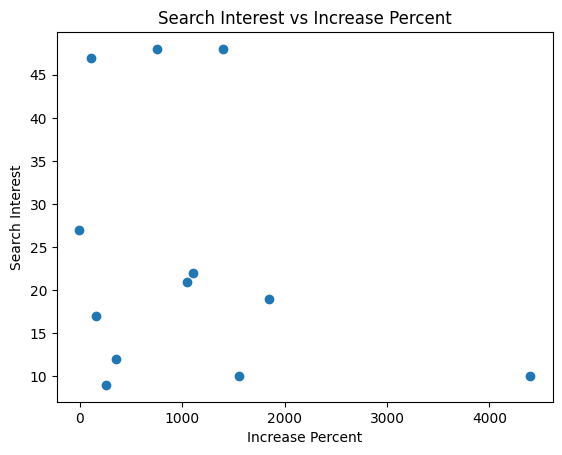

In [46]:
# Visualize using Scatter Plot

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['increase_percent'], df['search_interest'])
plt.xlabel("Increase Percent")
plt.ylabel("Search Interest")
plt.title("Search Interest vs Increase Percent")
plt.show()

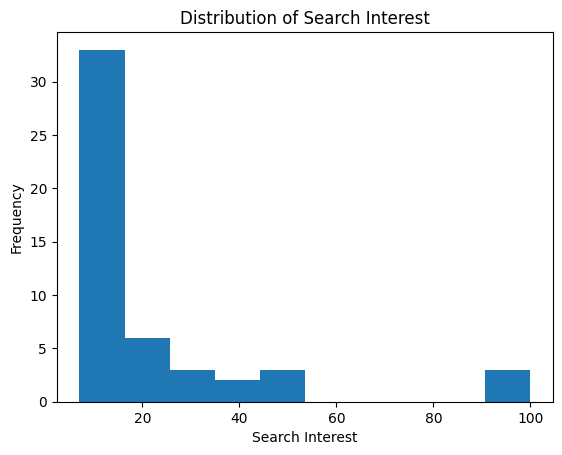

In [47]:
# Distribution Analysis -Search Interest

# Plot Histogram

plt.figure()
plt.hist(df['search_interest'], bins=10)
plt.xlabel("Search Interest")
plt.ylabel("Frequency")
plt.title("Distribution of Search Interest")
plt.show()



In [49]:
# Check Skewness Numerically
# If>0 Right-skewed (Positive skew)

skewness = df['search_interest'].skew()
print("Skewness Value:", skewness)

Skewness Value: 2.605923018697847


In [ ]:
# Add Mean & Median Comparison
# If Mean > Median → Right-skewed distribution
# If Mean < Median → Left-skewed distribution

mean_value = df['search_interest'].mean()
median_value = df['search_interest'].median()

print("Mean:", mean_value)
print("Median:", median_value)

Mean: 21.02
Median: 12.0
